In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DVS Assigment/India_VAHAN_Dataset.csv')

In [ ]:
df.head()

,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
0,REG100001,13-12-2019,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400,2,5
1,REG100002,14-01-2020,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400,2,4
2,REG100003,23-03-2023,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,250,2,1
3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3
4,REG100005,13-11-2022,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598,6,2


In [ ]:
df.describe()

,Registration_Year,Engine_CC,Seating_Capacity,Vehicle_Age_Years
count,3700.000000,3700.000000,3700.000000,3700.000000
mean,2021.675405,967.169459,6.667838,2.324595
std,1.742645,1488.601119,9.642442,1.742645
min,2018.000000,0.000000,1.000000,0.000000
25%,2020.000000,0.000000,2.000000,1.000000
50%,2022.000000,200.000000,3.000000,2.000000
75%,2023.000000,1462.000000,7.000000,4.000000
max,2024.000000,6700.000000,52.000000,6.000000


In [ ]:
col_list = df.columns.tolist()
col_list

['Registration_Number',
 'Registration_Date',
 'Registration_Year',
 'State',
 'RTO_Office',
 'Vehicle_Category',
 'Vehicle_Sub_Type',
 'Manufacturer_Brand',
 'Fuel_Type',
 'Emission_Norm',
 'Engine_CC',
 'Seating_Capacity',
 'Vehicle_Age_Years']

In [ ]:
non_num_cols = df.select_dtypes(exclude=['number']).columns.tolist()
num_cols = list(set(col_list) - set( non_num_cols ))
print( 'non_num_cols', non_num_cols)
print("num_cols",num_cols)

non_num_cols ['Registration_Number', 'Registration_Date', 'State', 'RTO_Office', 'Vehicle_Category', 'Vehicle_Sub_Type', 'Manufacturer_Brand', 'Fuel_Type', 'Emission_Norm']
num_cols ['Registration_Year', 'Engine_CC', 'Vehicle_Age_Years', 'Seating_Capacity']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3700 entries, 0 to 3699
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Registration_Number  3700 non-null   object
 1   Registration_Date    3700 non-null   object
 2   Registration_Year    3700 non-null   int64 
 3   State                3700 non-null   object
 4   RTO_Office           3700 non-null   object
 5   Vehicle_Category     3700 non-null   object
 6   Vehicle_Sub_Type     3700 non-null   object
 7   Manufacturer_Brand   3700 non-null   object
 8   Fuel_Type            3700 non-null   object
 9   Emission_Norm        3700 non-null   object
 10  Engine_CC            3700 non-null   int64 
 11  Seating_Capacity     3700 non-null   int64 
 12  Vehicle_Age_Years    3700 non-null   int64 
dtypes: int64(4), object(9)
memory usage: 375.9+ KB


<Axes: >

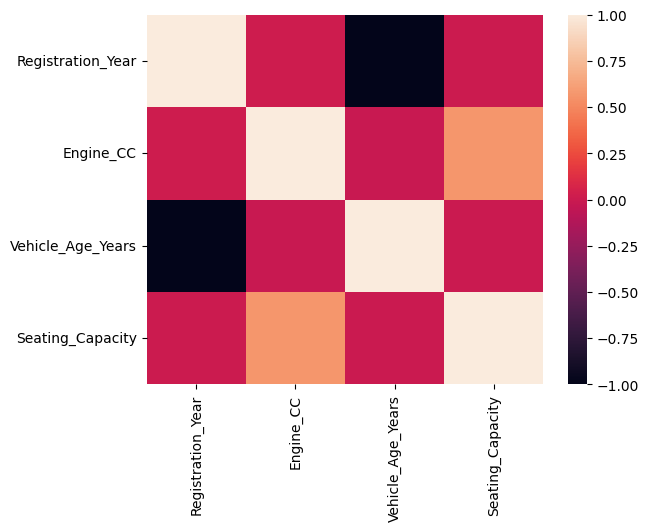

In [ ]:
sns.heatmap(df[num_cols].corr())

obviously Engine_CC and Seating_Capacity are positively corr;
and, Vehicle_Age_Years and Registration_Year are highly negatively corr

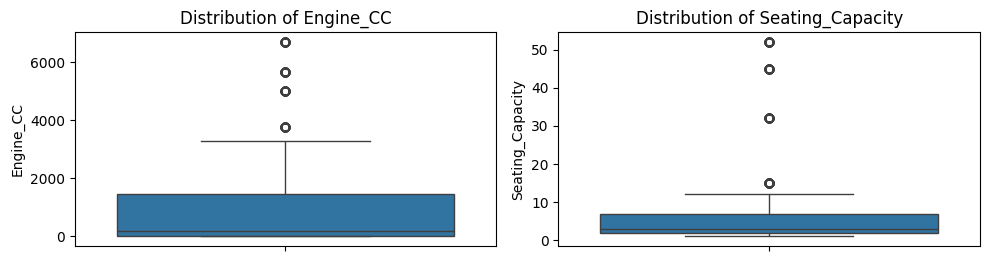

In [ ]:
plt.figure(figsize=(10, 5))
for i, col in enumerate( list( set(num_cols) - set(['Registration_Year','Vehicle_Age_Years'])) , 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df[col])
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

Seating capacity and engine CC is heavily skewed

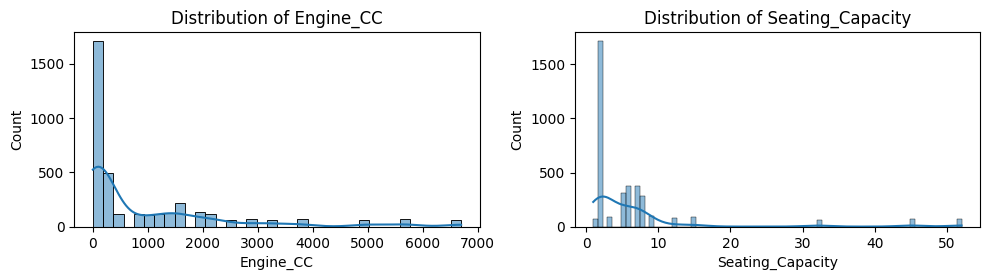

In [ ]:
plt.figure(figsize=(10, 5))
for i, col in enumerate( list( set(num_cols) - set(['Registration_Year','Vehicle_Age_Years'])) , 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df[col],kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [ ]:
df[df['Engine_CC']==0]

,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,0,2,3
7,REG100008,19-12-2021,2021,Karnataka,Ludhiana (PB-10),4W,Sedan,Tata Motors,Diesel,BS6,0,6,3
9,REG100010,13-03-2022,2022,Karnataka,Amritsar (PB-02),2W,Scooter,Suzuki,EV,BS6,0,2,2
11,REG100012,02-11-2019,2019,Karnataka,Mumbai Central (MH-01),2W,Motorcycle,Suzuki,EV,BS4,0,2,5
13,REG100014,24-02-2023,2023,Karnataka,Rajkot (GJ-03),2W,Motorcycle,Royal Enfield,EV,BS6,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,REG103680,08-05-2023,2023,Punjab,Patiala (PB-11),3W,E-Rickshaw,Kinetic Green,CNG,BS6,0,6,1
3681,REG103682,21-01-2023,2023,Maharashtra,Nashik (MH-15),LCV,Pickup Van,Tata Motors,Diesel,BS6,0,9,1
3682,REG103683,20-09-2022,2022,West Bengal,Asansol (WB-39),2W,Moped,Royal Enfield,EV,BS6,0,2,2
3687,REG103688,12-08-2023,2023,Punjab,Ludhiana (PB-10),2W,Motorcycle,Hero,EV,BS6,0,2,1


1114 entries have 0 engine CC

## Finding Categories and their subtypes

In [ ]:
df['Vehicle_Category'].unique()

array(['2W', '4W', 'LCV', 'OTH', '3W', 'HCV'], dtype=object)

In [ ]:
df.groupby('Vehicle_Category')['Vehicle_Sub_Type'].unique()

,Vehicle_Sub_Type
Vehicle_Category,
2W,"[Scooter, Motorcycle, Moped]"
3W,"[Tempo, Auto Rickshaw, E-Rickshaw]"
4W,"[Hatchback, Sedan, MUV, SUV]"
HCV,"[Bus, Tanker, Trailer, Truck]"
LCV,"[Mini Truck, Light Bus, Pickup Van]"
OTH,"[Tractor, Road Roller, Crane]"


In [ ]:
df.groupby(['Vehicle_Category', 'Vehicle_Sub_Type']).size().reset_index(name='Count')

,Vehicle_Category,Vehicle_Sub_Type,Count
0,2W,Moped,520
1,2W,Motorcycle,517
2,2W,Scooter,611
3,3W,Auto Rickshaw,83
4,3W,E-Rickshaw,96
5,3W,Tempo,102
6,4W,Hatchback,266
7,4W,MUV,299
8,4W,SUV,315
9,4W,Sedan,280


In [ ]:
df.groupby('Vehicle_Sub_Type')['Seating_Capacity'].unique()

,Seating_Capacity
Vehicle_Sub_Type,
Auto Rickshaw,"[7, 3, 6]"
Bus,"[45, 2, 52, 1, 32]"
Crane,"[1, 52, 2, 45, 32]"
E-Rickshaw,"[7, 6, 3]"
Hatchback,"[6, 5, 7, 8]"
Light Bus,"[12, 15, 9]"
MUV,"[5, 7, 8, 6]"
Mini Truck,"[9, 15, 12]"
Moped,[2]


So many seating capacities in so many sub categories seem bogus.


Here is the researched compliacne values of seating capacities accoess sub categories -
To double-validate seating capacity values across Indian states, we must cross-reference them with the **Motor Vehicles Act (MVA), 1988**, the **Central Motor Vehicles Rules (CMVR), 1989**, and **Automotive Industry Standards (AIS)** (such as AIS-052 for Buses and AIS-160 for Construction Equipment).

While state-level Regional Transport Offices (RTOs) enforce local permit conditions, **vehicle seating capacity is strictly governed at the national level by the Type Approval Certificate (TAC)** issued by testing agencies like ARAI, ICAT, and CIRT under CMVR Rule 126. State RTOs cannot alter manufacturer TAC limits during registration.

---

 1. Statutory Rules & Vehicle Classification Standards

| CMVR Category / AIS Standard | Vehicle Sub-Types Included | Statutory Seating Capacity Definition | Legal Limit (Persons) |
| --- | --- | --- | --- |
| **Category L1 / L2** | Moped, Motorcycle, Scooter | 2-wheeled motor vehicles designed for up to 2 occupants. | **Max 2** (Driver + 1 Pillion) |
| **Category L5M / E-Rickshaw** | Auto Rickshaw, E-Rickshaw | 3-wheeled passenger motor vehicles. CMVR limits E-rickshaws to 4 passengers + 1 driver. Shared autos are capped by State Transport Authorities (STA). | **3 to 7** *(3, 6 passengers; 4, 7 incl. driver)* |
| **Category M1** | Hatchback, Sedan, SUV, MUV | Motor vehicles with at least 4 wheels for passenger carriage, comprising **no more than 8 seats in addition to driver's seat**. | **Hatchback/Sedan:** Max 5 **SUV/MUV:**| 5 to 8 |
| **Category M2 / M3** | Light Bus (Maxi Cab), Heavy Bus | **M2 (Maxi Cab):** 6 to 12 passengers excluding driver.<br>

<br>**M3 (Bus Body Code AIS-052):** Heavy passenger vehicles over 13 seats. | **Light Bus:** 9 to 20<br>

<br>**Bus:** 26 to 60+ |
| **Category N1 / N2 / N3** | Mini Truck, Pickup Van, Truck, Tanker, Trailer | Goods carriages designed to carry goods. Seating capacity is **restricted to driver & cabin attendants** (CMVR Rule 100). | **Goods Cabins:** 2 to 3<br>

<br>*(Crew cab Pickups: Max 5)* |
| **Agricultural / CEV** | Tractor, Crane, Road Roller | **CMVR Rule 2(b) & 2(ca):** Non-transport machinery / agricultural equipment designed for field operations or construction. | **Tractor:** 1 or 2<br>

<br>**Crane / Roller:** 1 or 2 |

---

 2. Granular Validation Against RTO Records

🔴 Category-Level Field Leaks (Major Errors)

In Indian RTO databases (such as *VAHAN*), these errors usually stem from **Form 20/21 data entry misalignments**, where drop-down options shift during batch imports:

1. **Heavy Goods & Heavy Machinery (`Crane`, `Road Roller`, `Tractor`, `Trailer`, `Truck`, `Tanker`)**
* **Dataset Values Given:** `[1, 2, 32, 45, 52]`
* **CMVR Rule:** Heavy goods cabins are certified for **2 or 3 persons** max. Construction Equipment Vehicles (CEV) like Cranes/Road Rollers and Agricultural Tractors are certified for **1 or 2 persons**.
* **Validation Result:** Values **`32, 45, 52` are 100% invalid**. They represent omnibus/bus seating standards accidentally mapped to heavy machinery and trucks.


2. **Light Commercial Goods (`Mini Truck`, `Pickup Van`)**
* **Dataset Values Given:** `[9, 12, 15]`
* **CMVR Rule:** Mini trucks (e.g., Tata Ace) and Single-cab Pickup Vans are rated for **2 or 3 persons** in the front cabin (or up to **5** in double/crew cabs).
* **Validation Result:** Values **`9, 12, 15` are 100% invalid**. This is a classic cross-category leak from **Category M2 Maxi Cabs / Light Buses** (e.g., Force Traveller 9/12/15 seaters).


3. **Passenger Cars (`Hatchback`, `Sedan`)**
* **Dataset Values Given:** `[5, 6, 7, 8]`
* **CMVR Category M1 Rule:** Standard production hatchbacks and sedans in India are TAC-certified exclusively as 4 or 5-seaters (Driver + 3 or 4 passengers).
* **Validation Result:** Values **`6, 7, 8` are invalid** for Hatchbacks and Sedans. These values belong strictly to MUVs/SUVs (e.g., Innova, Ertiga, Scorpio).



---

🟡 Partial Anomalies & RTO Data Ambiguities

1. **Auto Rickshaw (`[3, 6, 7]`) & E-Rickshaw (`[3, 6, 7]`)**
* **Auto Rickshaw:**
* `3` = Registered passenger capacity (excluding driver) for standard autos.
* `6` = Shared Auto Cabs approved under State Motor Vehicle Rules in states like Maharashtra, UP, and Gujarat.
* `7` = Total capacity including driver on a 6-passenger permit. **Valid.**


* **E-Rickshaw:**
* Under CMVR Special Notification for Battery Operated Vehicles (Rule 2n), E-rickshaw capacity is **strictly capped at 4 passengers + 1 driver (Total 5)**.
* **Validation Result:** Values `6` and `7` in E-Rickshaws violate national safety norms and represent illegal modifications or bad RTO entries.




2. **Heavy Bus (`[1, 2, 32, 45, 52]`)**
* **AIS-052 Bus Body Code:** `32`, `45`, and `52` are standard seating configurations for 9m to 12m buses.
* **Validation Result:** Values `1` and `2` are invalid for standard buses (likely entered when registering a chassis before body building or reflecting driver-only entries).





In [ ]:
# Updated Cleaning logic mapping for standard RTO seating capacity ranges
# Accounts for both passenger capacity and total capacity (including driver)
RTO_VALID_CAPACITIES = {
    # Two-Wheelers (Category L1/L2: Driver + Pillion)
    "Moped": [2],
    "Motorcycle": [2],
    "Scooter": [2],

    # Three-Wheelers (Category L5M / E-Rickshaw)
    # 3, 4 = Standard Autos (3 passengers OR 3 + 1 driver)
    # 6, 7 = Shared / High-capacity Autos (6 passengers OR 6 + 1 driver)
    "Auto Rickshaw": [3, 4, 6, 7],

    # CMVR Rule 2(cb): Capped at 4 passengers + 1 driver
    # 3, 4 = Passengers | 4, 5 = Total Capacity
    "E-Rickshaw": [3, 4, 5],

    # Small Passenger / Intermediate Cabs
    "Tempo": [3, 6, 7, 9, 12, 13, 14],

    # Passenger Four-Wheelers (Category M1)
    # 4 added for micro-hatchbacks / 4-seater luxury coupes
    "Hatchback": [4, 5],
    "Sedan": [4, 5],
    "SUV": [5, 6, 7, 8],
    "MUV": [5, 6, 7, 8],

    # Commercial Passenger Vehicles (Category M2 / M3)
    "Light Bus": [9, 12, 13, 14, 15, 17, 20],
    "Bus": [26, 32, 36, 40, 45, 50, 52, 56, 60],

    # Goods Light Commercial Vehicles (Category N1 Cabin Capacity)
    # 2, 3 = Single Cab | 5 = Dual/Crew Cab
    "Mini Truck": [2, 3],
    "Pickup Van": [2, 3, 5],

    # Heavy Goods & Machinery (Category N2/N3 & CEV Cabin Capacity)
    # Restricted strictly to driver + cabin helpers (1, 2, or 3)
    "Truck": [2, 3],
    "Tanker": [2, 3],
    "Trailer": [2, 3],
    "Crane": [1, 2],
    "Tractor": [1, 2],
    "Road Roller": [1, 2]
}

def validate_seating(row):
    sub_type = row['Vehicle_Sub_Type']
    capacity = row['Seating_Capacity']
    if sub_type in RTO_VALID_CAPACITIES:
        if capacity not in RTO_VALID_CAPACITIES[sub_type]:
            return np.nan
    return capacity

df['Seating_Capacity'] = df.apply(validate_seating, axis=1)
print("Null values in Seating_Capacity after cleaning:", df['Seating_Capacity'].isna().sum())

Null values in Seating_Capacity after cleaning: 867


In [ ]:
df.groupby('Vehicle_Sub_Type')['Seating_Capacity'].apply(lambda x: x.isna().sum()).reset_index(name='Invalid_Entries_Count').sort_values(by='Invalid_Entries_Count', ascending=False)

,Vehicle_Sub_Type,Invalid_Entries_Count
14,Sedan,208
4,Hatchback,187
10,Pickup Van,90
7,Mini Truck,88
3,E-Rickshaw,69
18,Trailer,50
19,Truck,47
15,Tanker,36
1,Bus,26
17,Tractor,26


Now we modally impute as per group wise mode

In [ ]:
# Final safety check: Cap LCV goods vehicles that were over-imputed by category mode
def final_rto_fix(row):
    sub = row['Vehicle_Sub_Type']
    cap = row['Seating_Capacity']
    if sub == 'Mini Truck' and cap > 3:
        return 2.0
    if sub == 'Pickup Van' and cap > 5:
        return 2.0
    return cap

df['Seating_Capacity'] = df.apply(final_rto_fix, axis=1)

print("Final check for invalid values (should be empty):")
for sub, valid_list in RTO_VALID_CAPACITIES.items():
    invalid = df[(df['Vehicle_Sub_Type'] == sub) & (~df['Seating_Capacity'].isin(valid_list))]
    if not invalid.empty:
        print(f"{sub}: {invalid['Seating_Capacity'].unique()}")

print("\nImputation successfully completed and validated.")
df

Final check for invalid values (should be empty):
E-Rickshaw: [nan]
Hatchback: [nan]
Sedan: [nan]
Bus: [nan]
Mini Truck: [nan]
Pickup Van: [nan]
Truck: [nan]
Tanker: [nan]
Trailer: [nan]
Crane: [nan]
Tractor: [nan]
Road Roller: [nan]

Imputation successfully completed and validated.


,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
0,REG100001,13-12-2019,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400.0,2.0,5
1,REG100002,14-01-2020,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400.0,2.0,4
2,REG100003,23-03-2023,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,250.0,2.0,1
3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,160.0,2.0,3
4,REG100005,13-11-2022,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598.0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3695,REG103696,06-09-2021,2021,Rajasthan,Kota (RJ-20),4W,MUV,Mahindra,Diesel,BS4,2179.0,6.0,3
3696,REG103697,17-06-2021,2021,Punjab,Patiala (PB-11),HCV,Bus,Volvo,CNG,BS6,4998.0,52.0,3
3697,REG103698,06-04-2020,2020,Karnataka,Hubli (KA-25),LCV,Light Bus,Mahindra,Diesel,BS4,2956.0,12.0,4
3698,REG103699,05-07-2020,2020,Gujarat,Surat (GJ-05),4W,Hatchback,Renault,Diesel,BS6,2179.0,NaN,4


In [ ]:
import pandas as pd
import numpy as np

# 1. Primary Imputation: Group by Vehicle_Sub_Type
df['Seating_Capacity'] = df.groupby('Vehicle_Sub_Type')['Seating_Capacity'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

# 2. Secondary Imputation (Fallback): Group by Vehicle_Category for remaining NaNs
df['Seating_Capacity'] = df.groupby('Vehicle_Category')['Seating_Capacity'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

# Verify final null count
final_null_count = df['Seating_Capacity'].isna().sum()
print(f"Final null values in Seating_Capacity: {final_null_count}")
df.head()

Final null values in Seating_Capacity: 0


,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
0,REG100001,13-12-2019,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400.0,2.0,5
1,REG100002,14-01-2020,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400.0,2.0,4
2,REG100003,23-03-2023,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,250.0,2.0,1
3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,160.0,2.0,3
4,REG100005,13-11-2022,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598.0,5.0,2


## Investigating Engine_CC = 0
We previously identified 1,114 records with 0 Engine CC. Let's check if these correlate with Electric Vehicles (EVs) or if they represent missing data for fuel-based vehicles.

In [ ]:
# Breakdown of Engine_CC = 0 by Fuel_Type and Vehicle_Category
engine_zero_analysis = df[df['Engine_CC'] == 0].groupby(['Fuel_Type', 'Vehicle_Category']).size().reset_index(name='Zero_CC_Count')
print("Distribution of Zero Engine_CC:")
print(engine_zero_analysis)

# Check for anomalies: Non-EVs with 0 Engine_CC
anomalous_zeros = df[(df['Engine_CC'] == 0) & (df['Fuel_Type'] != 'EV')]
print(f"\nNumber of non-EV records with 0 Engine_CC: {len(anomalous_zeros)}")
if not anomalous_zeros.empty:
    print("\nSample of anomalous zero-CC records:")
    print(anomalous_zeros[['Vehicle_Sub_Type', 'Fuel_Type', 'Manufacturer_Brand']].head())

Distribution of Zero Engine_CC:
   Fuel_Type Vehicle_Category  Zero_CC_Count
0        CNG               2W             11
1        CNG               3W             27
2        CNG               4W              7
3        CNG              HCV              4
4        CNG              LCV             15
5     Diesel               3W             14
6     Diesel               4W             38
7     Diesel              HCV             34
8     Diesel              LCV             40
9     Diesel              OTH             19
10        EV               2W            502
11        EV               3W             71
12        EV               4W            132
13        EV              HCV             14
14        EV              LCV             29
15    Hybrid               2W              5
16    Hybrid               4W              7
17    Petrol               2W             91
18    Petrol               3W              5
19    Petrol               4W             47
20    Petrol           

## Imputing Engine_CC for Non-EV Anomalies
We will replace 0 CC values with `NaN` for non-EV vehicles and then use group-wise median imputation (by Sub-Type and Fuel) to fill them.

In [ ]:
# 1. Mark 0 CC as NaN ONLY for non-EV/Hybrid vehicles where 0 is invalid
# Note: Hybrid vehicles usually still have a combustion engine CC rating.
df.loc[(df['Engine_CC'] == 0) & (df['Fuel_Type'] != 'EV'), 'Engine_CC'] = np.nan

# 2. Impute using median of (Vehicle_Sub_Type + Fuel_Type)
df['Engine_CC'] = df.groupby(['Vehicle_Sub_Type', 'Fuel_Type'])['Engine_CC'].transform(lambda x: x.fillna(x.median()))

# 3. Final safety: If any still null (rare cases), use Vehicle_Sub_Type median
df['Engine_CC'] = df.groupby('Vehicle_Sub_Type')['Engine_CC'].transform(lambda x: x.fillna(x.median()))

print("Remaining nulls in Engine_CC:", df['Engine_CC'].isna().sum())

Remaining nulls in Engine_CC: 0


## Final Engine_CC Verification
Let's verify that the only vehicles with 0 CC are now Electric Vehicles (EVs) and visualize the cleaned distribution for non-EVs.

In [ ]:
# Detailed breakdown of Engine_CC ranges by Sub-Category and Fuel Type
fuel_sub_range = df.groupby(['Vehicle_Sub_Type', 'Fuel_Type'])['Engine_CC'].agg(['min', 'median', 'max', 'count']).reset_index()

# Sort for easier comparison
fuel_sub_range = fuel_sub_range.sort_values(['Vehicle_Sub_Type', 'median'])

print("Engine_CC Range Summary (Fuel-wise per Sub-Category):")
print(fuel_sub_range.to_string(index=0))

Engine_CC Range Summary (Fuel-wise per Sub-Category):
Vehicle_Sub_Type Fuel_Type    min  median    max  count
   Auto Rickshaw        EV    0.0     0.0    0.0     20
   Auto Rickshaw       CNG  200.0   225.0  250.0     37
   Auto Rickshaw    Diesel  200.0   225.0  250.0     20
   Auto Rickshaw    Petrol  200.0   225.0  250.0      6
             Bus        EV    0.0     0.0    0.0      3
             Bus       CNG 3760.0  4998.0 6700.0      8
             Bus    Diesel 3760.0  5660.0 6700.0     58
           Crane    Diesel 3760.0  4998.0 6700.0     38
           Crane    Petrol 5660.0  6180.0 6700.0      2
      E-Rickshaw        EV    0.0     0.0    0.0     24
      E-Rickshaw    Petrol  200.0   200.0  225.0      9
      E-Rickshaw       CNG  200.0   225.0  250.0     49
      E-Rickshaw    Diesel  200.0   225.0  250.0     14
       Hatchback        EV    0.0     0.0    0.0     34
       Hatchback    Hybrid 1000.0  1462.0 2179.0     14
       Hatchback       CNG  800.0  1498.0 2179.0  

In [ ]:
df['Vehicle_Sub_Type'].unique()

array(['Scooter', 'Motorcycle', 'Hatchback', 'Sedan', 'Mini Truck', 'MUV',
       'Tractor', 'Moped', 'SUV', 'Tempo', 'Auto Rickshaw', 'Bus',
       'Road Roller', 'Light Bus', 'Tanker', 'Trailer', 'E-Rickshaw',
       'Pickup Van', 'Crane', 'Truck'], dtype=object)

In [ ]:
df

,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
0,REG100001,13-12-2019,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400.0,2.0,5
1,REG100002,14-01-2020,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400.0,2.0,4
2,REG100003,23-03-2023,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,250.0,2.0,1
3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,160.0,2.0,3
4,REG100005,13-11-2022,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598.0,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3695,REG103696,06-09-2021,2021,Rajasthan,Kota (RJ-20),4W,MUV,Mahindra,Diesel,BS4,2179.0,6.0,3
3696,REG103697,17-06-2021,2021,Punjab,Patiala (PB-11),HCV,Bus,Volvo,CNG,BS6,4998.0,52.0,3
3697,REG103698,06-04-2020,2020,Karnataka,Hubli (KA-25),LCV,Light Bus,Mahindra,Diesel,BS4,2956.0,12.0,4
3698,REG103699,05-07-2020,2020,Gujarat,Surat (GJ-05),4W,Hatchback,Renault,Diesel,BS6,2179.0,NaN,4


In [ ]:
# 1. Check if Registration_Year + Vehicle_Age_Years consistently equals current year
cur_yr = 2024 # date.today().year will not work as this dataset is based on data till 2024
df['Calculated_Current_Year'] = df['Registration_Year'] + df['Vehicle_Age_Years']
age_mismatch = df[df['Calculated_Current_Year'] != (cur_yr)]

# 2. Check for future registration years (greater than cur_yr)
future_registrations = df[df['Registration_Year'] > cur_yr]

print(f"Records where Age + Reg_Year != cur_yr: {len(age_mismatch)}")
print(f"Records with future Registration_Year (> cur_yr): {len(future_registrations)}")

if not age_mismatch.empty:
    print("\nSample of age/year mismatches:")
    print(age_mismatch[['Registration_Year', 'Vehicle_Age_Years', 'Calculated_Current_Year']].head())

# Drop the helper column after check
df.drop(columns=['Calculated_Current_Year'], inplace=True)

Records where Age + Reg_Year != cur_yr: 0
Records with future Registration_Year (> cur_yr): 0


In [ ]:
df

,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
0,REG100001,13-12-2019,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400.0,2.0,5
1,REG100002,14-01-2020,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400.0,2.0,4
2,REG100003,23-03-2023,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,250.0,2.0,1
3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,160.0,2.0,3
4,REG100005,13-11-2022,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598.0,5.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3695,REG103696,06-09-2021,2021,Rajasthan,Kota (RJ-20),4W,MUV,Mahindra,Diesel,BS4,2179.0,6.0,3
3696,REG103697,17-06-2021,2021,Punjab,Patiala (PB-11),HCV,Bus,Volvo,CNG,BS6,4998.0,52.0,3
3697,REG103698,06-04-2020,2020,Karnataka,Hubli (KA-25),LCV,Light Bus,Mahindra,Diesel,BS4,2956.0,12.0,4
3698,REG103699,05-07-2020,2020,Gujarat,Surat (GJ-05),4W,Hatchback,Renault,Diesel,BS6,2179.0,5.0,4


In [ ]:
df['Seating_Capacity'] = df['Seating_Capacity'].astype(int)

In [ ]:
df.head()

,Registration_Number,Registration_Date,Registration_Year,State,RTO_Office,Vehicle_Category,Vehicle_Sub_Type,Manufacturer_Brand,Fuel_Type,Emission_Norm,Engine_CC,Seating_Capacity,Vehicle_Age_Years
0,REG100001,13-12-2019,2019,Madhya Pradesh,Bhopal (MP-04),2W,Scooter,Bajaj,Petrol,BS4,400.0,2,5
1,REG100002,14-01-2020,2020,Karnataka,Belgaum (KA-22),2W,Motorcycle,Honda,Petrol,BS6,400.0,2,4
2,REG100003,23-03-2023,2023,Karnataka,Delhi South (DL-09),2W,Scooter,Ola Electric,Petrol,BS6,250.0,2,1
3,REG100004,26-06-2021,2021,Karnataka,Kota (RJ-20),2W,Scooter,Honda,Petrol,BS6,160.0,2,3
4,REG100005,13-11-2022,2022,Karnataka,Ahmedabad (GJ-01),4W,Hatchback,Honda,Petrol,BS6,1598.0,5,2


In [ ]:
df.to_csv('/content/drive/MyDrive/DVS Assigment/cleaned_dvs_data.csv', index=False)